# SciPy Bootcamp — Week 1, Day 4B
```
##### ANCOVA, Two-Way ANOVA & Repeated Measures ANOVA
##### ANCOVA as regression, interaction effects, within-subject designs
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Q1 (ANCOVA — controlling for a covariate): MedPulse session duration differs across 3 content types (news, opinion, feature).
#     Add article_length as a covariate. Run plain ANOVA then ANCOVA. Does controlling for article_length change conclusions?
##### Q2 (Two-way ANOVA — interaction effects): Test layout (A vs B) x device (mobile vs desktop) on session duration.
#     Does the layout effect depend on device type? Interpret the interaction term.
##### Q3 (Repeated measures ANOVA): 80 users measured at Week 1, Week 2, Week 4 after a redesign.
#     Run AnovaRM. If significant, run pairwise paired t-tests with Bonferroni correction.
##### Q4 (ANCOVA as regression — unify the models): Show that ANOVA, ANCOVA, and OLS regression are the same model.
#     Run all three on the same data and show the group p-value is identical across all three.
##### Q5 (Parametric assumptions check for Day 4B methods): For a given dataset,
#     test all relevant assumptions before choosing between Day 4A/4B (parametric) and Day 4C (non-parametric).
#     Build a reusable assumption_check() function that runs Shapiro-Wilk and Levene and returns a recommendation.

In [48]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM, anova_lm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — ANCOVA — controlling for a covariate

```
MedPulse: does content type (news / opinion / feature) affect time-on-page
# after controlling for article length?
# Simulate:
#   n=150 total, 50 per group
#   article_length ~ Uniform(300, 2000) for all groups
#   time_on_page = 0.002 * article_length + group_offset + noise
#   group offsets: news=0, opinion=0.5, feature=1.0
# (a) Run plain one-way ANOVA (ignoring article_length). Print p-value.
# (b) Run ANCOVA controlling for article_length. Print p-value.
# (c) Compare: does the group effect change after controlling for length?
# (d) Plot residuals vs fitted values for the ANCOVA model.
# (e) Write a comment explaining what ANCOVA is doing in plain English.
```


In [49]:
# Q1: ANCOVA — controlling for a covariate
# Chart + analysis woven together — visualize as you discover

In [50]:
# (a) Run plain one-way ANOVA (ignoring article_length). Print p-value.

np.random.seed(42)
n_per_group = 50
n_total = 150

# group designations
groups = ['news'] * n_per_group + ['opinion'] * n_per_group + ['feature'] * n_per_group

# article length ~ Uniform(300, 2000)
article_length = np.random.uniform(300, 2000, n_total)

# offset
group_offset = np.array([0.0] * n_per_group + [0.5] * n_per_group + [1.0] * n_per_group)

# noise
noise = np.random.normal(0, 0.5, n_total)

# time_on_page = 0.002 * article_length + group_offset + noise
time_on_page = 0.002 * article_length + group_offset + noise

df = pd.DataFrame({
    'content_type': groups,
    'article_length': article_length,
    'time_on_page': time_on_page
})

df.head()

,content_type,article_length,time_on_page
0,news,936.718202,1.777256
1,news,1916.214321,3.983202
2,news,1544.389701,3.071424
3,news,1317.719423,2.051100
4,news,565.231689,1.701875


In [51]:
# Run plain one-way ANOVA
import statsmodels.api as sm

model_anova = smf.ols('time_on_page ~ C(content_type)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)
print()
print(f"Content Type P-Value: {anova_table.loc['C(content_type)', 'PR(>F)']}")

                     sum_sq     df          F    PR(>F)
C(content_type)   30.672491    2.0  11.464847  0.000024
Residual         196.638302  147.0        NaN       NaN

Content Type P-Value: 2.360653448205997e-05


In [ ]:
# (b) Run ANCOVA controlling for article_length. Print p-value.
model_ancova = smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
ancova_table = sm.stats.anova_lm(model_ancova, typ=2)
print(ancova_table)
print()
print(f"Content Type P-Value: {ancova_table.loc['C(content_type)', 'PR(>F)']}")
print(f"Article Length P-Value: {ancova_table.loc['article_length', 'PR(>F)']}")

                     sum_sq     df           F        PR(>F)
C(content_type)   23.425896    2.0   44.025854  1.091431e-15
article_length   157.795434    1.0  593.111038  2.805683e-53
Residual          38.842867  146.0         NaN           NaN

Content Type P-Value: 1.0914305992301007e-15
Article Length P-Value: 2.805683238232285e-53


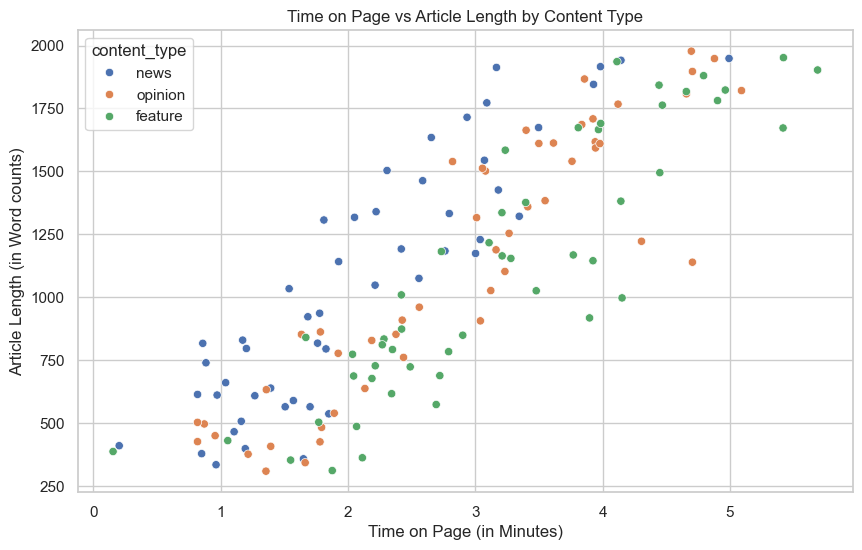

In [94]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='time_on_page', y='article_length', hue='content_type', alpha=1)

plt.xlabel('Time on Page (in Minutes)')
plt.ylabel('Article Length (in Word counts)')
plt.title('Time on Page vs Article Length by Content Type')

plt.show()

```
(c) Compare: does the group effect change after controlling for length?
Yes, the group effect became much more evident.
While the direction of the effect didn't change (Features are still the longest), the precision of your estimate increased drastically. 
Controlling for length allowed you to separate "long because it's a deep-dive Feature" from "long because it's just a high word count."

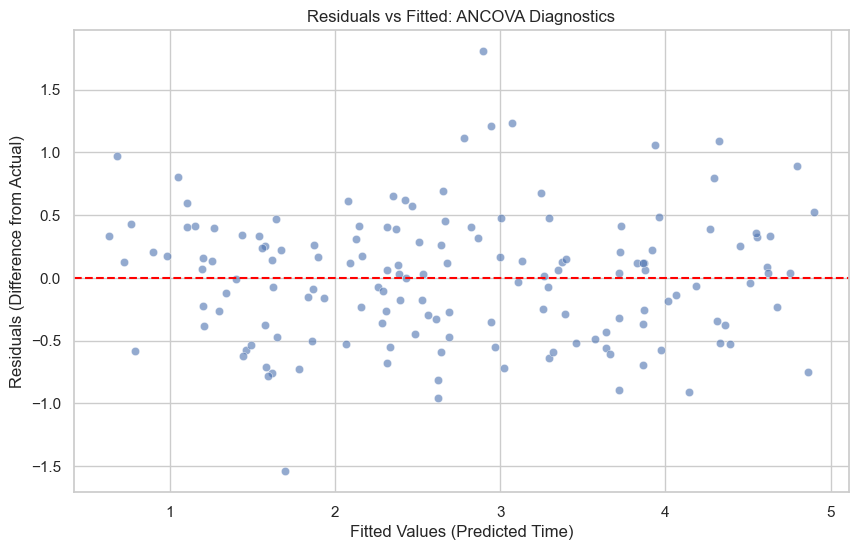

In [ ]:
# (d) Plot residuals vs fitted values for the ANCOVA model.

fitted      = model_ancova.fittedvalues
residuals   = model_ancova.resid

plt.figure(figsize=(10,6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel('Fitted Values (Predicted Time)')
plt.ylabel('Residuals (Difference from Actual)')
plt.title('Residuals vs Fitted: ANCOVA Diagnostics')

plt.show()

```
(e) Write a comment explaining what ANCOVA is doing in plain English.
Think of ANCOVA as a "Fairness Filter" for the data. 
Its main goal is to see if groups are actually different by removing the "head start" some data points got from another variable.

---

### Q2 — Two-way ANOVA — interaction effects

```
Test whether layout (A vs B) AND device (mobile vs desktop) affect session duration.
# layout_A_mobile  = Normal(3.2, 1.0, 50)
# layout_A_desktop = Normal(4.8, 1.1, 50)
# layout_B_mobile  = Normal(4.1, 1.0, 50)
# layout_B_desktop = Normal(4.9, 1.1, 50)
# (a) Build a tidy DataFrame: duration, layout, device
# (b) Run: smf.ols('duration ~ C(layout) * C(device)', data=df).fit()
#     Print anova_lm(model, typ=2) — Type II ANOVA table
# (c) Is the interaction C(layout):C(device) significant?
#     Interpret in plain English: does layout work differently on mobile vs desktop?
# (d) Plot interaction plot: x=device, y=mean duration, hue=layout.
#     Crossing lines = interaction. Parallel lines = additive effects only.
```


In [55]:
# Q2: Two-way ANOVA — interaction effects
# Chart + analysis woven together — visualize as you discover

In [ ]:
layout_A_mobile  = np.random.normal(3.2, 1.0, 50)
layout_A_desktop = np.random.normal(4.8, 1.1, 50)
layout_B_mobile  = np.random.normal(4.1, 1.0, 50)
layout_B_desktop = np.random.normal(4.9, 1.1, 50)

In [ ]:
# (a) Build a tidy DataFrame: duration, layout, device
df2 = pd.DataFrame({
    'device': np.repeat(['mobile', 'desktop'], 100),
    'layout': np.tile(['A', 'B'], 100)
})

df2.loc[(df2['device']=='mobile') & (df2['layout']=='A'),'duration']   = layout_A_mobile
df2.loc[(df2['device']=='desktop') & (df2['layout']=='A'),'duration']  = layout_A_desktop
df2.loc[(df2['device']=='mobile') & (df2['layout']=='B'),'duration']   = layout_B_mobile
df2.loc[(df2['device']=='desktop') & (df2['layout']=='B'),'duration']  = layout_B_desktop


print(df2.head())
print(df2.tail())

   device layout  duration
0  mobile      A  2.947432
1  mobile      B  4.790144
2  mobile      A  1.952217
3  mobile      B  3.698780
4  mobile      A  4.832411
      device layout  duration
195  desktop      B  4.938790
196  desktop      A  4.680364
197  desktop      B  4.130302
198  desktop      A  5.241883
199  desktop      B  5.135378


In [47]:
# (b) Run: smf.ols('duration ~ C(layout) * C(device)', data=df).fit()
#     Print anova_lm(model, typ=2) — Type II ANOVA table
model_anova = smf.ols('duration ~ C(device) * C(layout)', data=df2).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)


                         sum_sq     df          F        PR(>F)
C(device)             61.973552    1.0  62.697721  1.753237e-13
C(layout)             10.074281    1.0  10.192000  1.643256e-03
C(device):C(layout)    8.159621    1.0   8.254967  4.512023e-03
Residual             193.736168  196.0        NaN           NaN


```
(c) Is the interaction C(layout):C(device) significant? Interpret in plain English: does layout work differently on mobile vs desktop?
The interaction is significant (p=0.0045), meaning layout does NOT work the same way across devices. 
Layout B disproportionately benefits mobile  users (+0.9 min) while barely moving desktop (+0.1 min), 
cutting the mobile/desktop gap in half from 1.6 to 0.8 minutes.

Business implication: if the goal is to lift mobile engagement, deploy Layout B. 
For desktop-only users, the layout choice is largely irrelevant.
Reporting only the main effects would have missed this entirely.

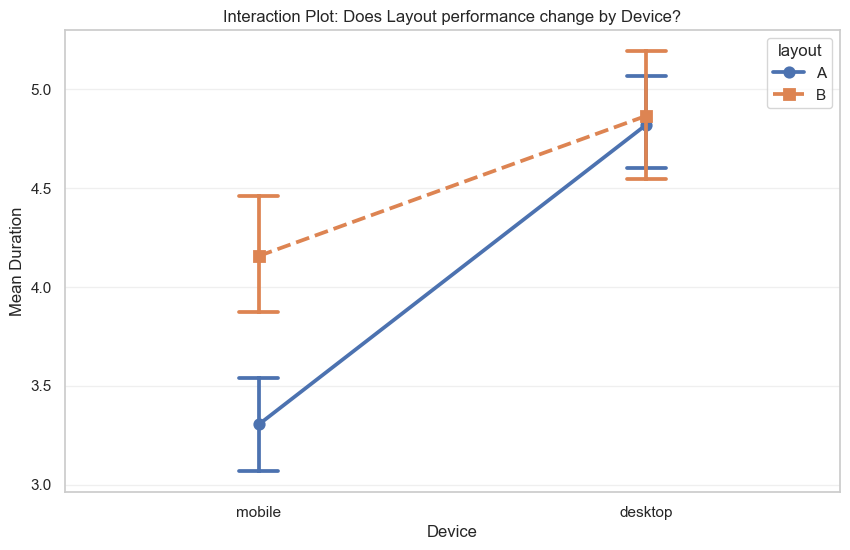

In [66]:
# (d) Plot interaction plot: x=device, y=mean duration, hue=layout.
#     Crossing lines = interaction. Parallel lines = additive effects only.
plt.figure(figsize=(10,6))
sns.pointplot(data=df2, x='device', y='duration', hue='layout', markers=['o','s'], linestyles=['-','--'], capsize=.1)


plt.title('Interaction Plot: Does Layout performance change by Device?')
plt.ylabel('Mean Duration')
plt.xlabel('Device')
plt.grid(axis='y', alpha=0.3)

plt.show()

---

### Q3 — Repeated measures ANOVA — same subjects, 3+ time points

```
80 users measured at Week 1, Week 2, and Week 4 after a platform redesign.
# (a) Simulate correlated repeated measurements:
#     base = Normal(3.5, 1.0, 80)  ← user baseline (between-subject variance)
#     week1 = base + Normal(0,   0.3, 80)
#     week2 = base + Normal(0.3, 0.3, 80)
#     week4 = base + Normal(0.6, 0.3, 80)
# (b) Build long-format DataFrame: Subject (0-79), Time (Week1/Week2/Week4), Score
# (c) Run: AnovaRM(df, depvar='Score', subject='Subject', within=['Time']).fit()
#     Print the summary — is the Time effect significant?
# (d) If significant: pairwise paired t-tests with Bonferroni correction
#     (Week1 vs Week2), (Week1 vs Week4), (Week2 vs Week4)
#     alpha_corrected = 0.05 / 3
# (e) Write a comment: why is repeated measures ANOVA more powerful
#     than running three independent one-way ANOVAs?
```


In [ ]:
# Q3: Repeated measures ANOVA — same subjects, 3+ time points
# Chart + analysis woven together — visualize as you discover

In [72]:
# (a) Simulate correlated repeated measurements:
np.random.seed(420)
n_subjects = 80
subject_ids = np.tile(range(n_subjects), 3) 
time_points = np.repeat(['Week1', 'Week2', 'Week4'], n_subjects)


# Simulate improving engagement over time
base = np.random.normal(3.5, 1.0, n_subjects)
scores = np.concatenate([
    base + np.random.normal(0, 0.3, n_subjects),    # Week 1
    base + np.random.normal(0.3, 0.3, n_subjects),  # Week 2
    base + np.random.normal(0.6, 0.3, n_subjects),  # Week 4
])

In [73]:
# (b) Build long-format DataFrame: Subject (0-79), Time (Week1/Week2/Week4), Score
df3 = pd.DataFrame({
    'Subject': subject_ids, 
    'Time': time_points, 
    'Score': scores
    })

df3.sample(5)

,Subject,Time,Score
109,29,Week2,4.975252
102,22,Week2,2.343758
7,7,Week1,3.279895
162,2,Week4,3.374271
98,18,Week2,3.467787


In [ ]:
# (c) Run: AnovaRM(df, depvar='Score', subject='Subject', within=['Time']).fit()
#     Print the summary — is the Time effect significant?

rm = AnovaRM(df3, depvar='Score', subject='Subject', within=['Time']).fit()
print(rm.summary()) 
#since p-value is way smaller than 0.05 so the Time effect is significant

               Anova
     F Value Num DF  Den DF  Pr > F
-----------------------------------
Time 88.9583 2.0000 158.0000 0.0000



In [77]:
# (d) If significant: pairwise paired t-tests with Bonferroni correction
#     (Week1 vs Week2), (Week1 vs Week4), (Week2 vs Week4)
#     alpha_corrected = 0.05 / 3

w1 = df3[df3['Time'] == 'Week1']['Score']
w2 = df3[df3['Time'] == 'Week2']['Score']
w4 = df3[df3['Time'] == 'Week4']['Score']

t12, p12 = stats.ttest_rel(w1, w2)
t14, p14 = stats.ttest_rel(w1, w4)
t24, p24 = stats.ttest_rel(w2, w4)

alpha_adj = 0.05 / 3
print(f"Bonferroni Threshold: {alpha_adj:.4f}")
print(f"W1 vs W2: p={p12:.4f} {'*' if p12 < alpha_adj else 'Not Significant'}")
print(f"W1 vs W4: p={p14:.4f} {'*' if p14 < alpha_adj else 'Not Significant'}")
print(f"W2 vs W4: p={p24:.4f} {'*' if p24 < alpha_adj else 'Not Significant'}")

Bonferroni Threshold: 0.0167
W1 vs W2: p=0.0000 *
W1 vs W4: p=0.0000 *
W2 vs W4: p=0.0000 *


```
(e) Write a comment: why is repeated measures ANOVA more powerful than running three independent one-way ANOVAs?
Repeated measures ANOVA is more powerful because it filters out individual differences by using each subject as their own control. 
By calculating a unique baseline for every person, the model can ignore the "noise" of why one user is naturally faster than another and focus strictly on how they change over time. 
This drastically reduces the error term (residuals), making it much easier to detect a statistically significant "signal" even with a smaller sample size.

---

### Q4 — ANCOVA as regression — the unified model

```
Using the same DataFrame from Q1 (content_type, time_on_page, article_length):
# (a) Run ANOVA:  smf.ols('time_on_page ~ C(content_type)', data=df).fit()
# (b) Run ANCOVA: smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
# (c) Run OLS:    smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
#     (this is the same as ANCOVA — show that p-values are identical)
# (d) Print the coefficient table from the OLS model.
#     Interpret: what does the coefficient on article_length mean?
# (e) Write a 3-sentence comment explaining why ANOVA, ANCOVA,
#     and linear regression are all the same underlying model (GLM).
```


In [ ]:
# Q4: ANCOVA as regression — the unified model
# Chart + analysis woven together — visualize as you discover

In [78]:
# (a) Run ANOVA:  smf.ols('time_on_page ~ C(content_type)', data=df).fit()
model_anova = smf.ols('time_on_page ~ C(content_type)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(anova_table)
print()
print(f"Content Type P-Value: {anova_table.loc['C(content_type)', 'PR(>F)']}")

                     sum_sq     df          F    PR(>F)
C(content_type)   30.672491    2.0  11.464847  0.000024
Residual         196.638302  147.0        NaN       NaN

Content Type P-Value: 2.360653448205997e-05


In [79]:
# (b) Run ANCOVA: smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
model_ancova = smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
ancova_table = sm.stats.anova_lm(model_ancova, typ=2)
print(ancova_table)
print()
print(f"Content Type P-Value: {ancova_table.loc['C(content_type)', 'PR(>F)']}")
print(f"Article Length P-Value: {ancova_table.loc['article_length', 'PR(>F)']}")


                     sum_sq     df           F        PR(>F)
C(content_type)   23.425896    2.0   44.025854  1.091431e-15
article_length   157.795434    1.0  593.111038  2.805683e-53
Residual          38.842867  146.0         NaN           NaN

Content Type P-Value: 1.0914305992301007e-15
Article Length P-Value: 2.805683238232285e-53


In [86]:
# (c) Run OLS:    smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
model_ols = smf.ols('time_on_page ~ C(content_type) + article_length', data=df).fit()
ols_table = sm.stats.anova_lm(model_ols, typ=2)
print(ols_table)
print()
print(f"Content Type P-Value: {ols_table.loc['C(content_type)', 'PR(>F)']}")
print(f"Article Length P-Value: {ols_table.loc['article_length', 'PR(>F)']}")

                     sum_sq     df           F        PR(>F)
C(content_type)   23.425896    2.0   44.025854  1.091431e-15
article_length   157.795434    1.0  593.111038  2.805683e-53
Residual          38.842867  146.0         NaN           NaN

Content Type P-Value: 1.0914305992301007e-15
Article Length P-Value: 2.805683238232285e-53


In [ ]:
# ANCOVA and OLS give the same group effect
# Extract p-values as scalars
ancova_p = ancova_table.loc['C(content_type)', 'PR(>F)']
ols_p    = ols_table.loc['C(content_type)', 'PR(>F)']

print(f"\nANCOVA p: {ancova_p:.6e}")
print(f"OLS p:    {ols_p:.6e}")
print(f"Identical: {np.isclose(ancova_p, ols_p)}")


ANCOVA p: 1.091431e-15
OLS p:    1.091431e-15
Identical: True


In [84]:
# (d) Print the coefficient table from the OLS model.
#     Interpret: what does the coefficient on article_length mean?
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:           time_on_page   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     236.1
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           8.56e-56
Time:                        23:55:51   Log-Likelihood:                -111.51
No. Observations:                 150   AIC:                             231.0
Df Residuals:                     146   BIC:                             243.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

```
Interpret: what does the coefficient on article_length mean?
For every 1 additional word added to an article, the time_on_page increases by 0.002 minutes (~0.12 seconds), assuming the content type stays the same.

```
(e) Write a 3-sentence comment explaining why ANOVA, ANCOVA, and linear regression are all the same underlying model (GLM).
ANOVA, ANCOVA, and linear regression are all specific versions of the General Linear Model (GLM) because they share the same fundamental math: predicting an outcome by calculating a "weighted sum" of predictors plus error. 
Whether the input is a category (ANOVA) or a continuous number (Regression), the model uses the same Least Squares logic to minimize the distance between your data points and the predicted values. 
Ultimately, they all solve the same equation (Y = beta * X + error), simply varying whether X represents a group label or a measured value.

---

### Q5 — Assumption check function — when to use 4A/4B vs 4C

```
Build a reusable assumption_check() function that:
# Input: *groups (any number of arrays), alpha=0.05
# (a) Runs stats.shapiro() on each group — tests normality
# (b) Runs stats.levene() across all groups — tests equal variances
# (c) Prints a clean summary table: group name, n, shapiro p-value, normal?
# (d) Returns a recommendation string:
#     'Use ANOVA (Day 4A/4B) — assumptions met'
#     'Use Kruskal-Wallis (Day 4C) — normality violated'
#     'Use Kruskal-Wallis (Day 4C) — equal variance violated'
# Test your function on:
#   - Three Normal groups (should recommend ANOVA)
#   - Three Lognormal groups with small n=20 (should recommend Kruskal-Wallis)
#   - Mixed: one Normal, two heavily skewed (should recommend Kruskal-Wallis)
```


In [ ]:
# Q5: Assumption check function — when to use 4A/4B vs 4C
# Chart + analysis woven together — visualize as you discover


In [85]:
def assumption_check(*groups, names=None, alpha=0.05):
    if names is None:
        names = [f"Group {i+1}" for i in range(len(groups))]
    
    results = []
    normality_met = True
    
    # (a) & (c) Shapiro-Wilk for each group
    for name, data in zip(names, groups):
        stat, p_val = stats.shapiro(data)
        is_normal = p_val > alpha
        if not is_normal:
            normality_met = False
        results.append({
            'Group': name,
            'n': len(data),
            'Shapiro p-value': round(p_val, 4),
            'Normal?': "Yes" if is_normal else "No"
        })
    
    # (b) Levene's Test for equal variances
    lev_stat, lev_p = stats.levene(*groups)
    variance_met = lev_p > alpha
    
    # Print Table
    df_results = pd.DataFrame(results)
    print("--- Normality Check (Shapiro-Wilk) ---")
    print(df_results.to_string(index=False))
    print(f"\n--- Variance Check (Levene's) ---")
    print(f"Levene p-value: {round(lev_p, 4)} | Equal Variance? {'Yes' if variance_met else 'No'}")
    
    # (d) Recommendations
    if not normality_met:
        return 'Recommendation: Use Kruskal-Wallis (Day 4C) — normality violated'
    if not variance_met:
        return 'Recommendation: Use Kruskal-Wallis (Day 4C) — equal variance violated'
    return 'Recommendation: Use ANOVA (Day 4A/4B) — assumptions met'

# Test Cases
np.random.seed(42)

print("\nTEST 1: THREE NORMAL GROUPS")
g1 = np.random.normal(10, 1, 50)
g2 = np.random.normal(10, 1, 50)
g3 = np.random.normal(10, 1, 50)
print(assumption_check(g1, g2, g3, names=['N1', 'N2', 'N3']))

print("\nTEST 2: THREE LOGNORMAL GROUPS (n=20)")
l1 = np.random.lognormal(0, 1, 20)
l2 = np.random.lognormal(0, 1, 20)
l3 = np.random.lognormal(0, 1, 20)
print(assumption_check(l1, l2, l3, names=['L1', 'L2', 'L3']))

print("\nTEST 3: MIXED (ONE NORMAL, TWO SKEWED)")
m1 = np.random.normal(10, 1, 50)
m2 = np.random.exponential(1, 50)
m3 = np.random.exponential(1, 50)
print(assumption_check(m1, m2, m3, names=['Normal', 'Skew1', 'Skew2']))



TEST 1: THREE NORMAL GROUPS
--- Normality Check (Shapiro-Wilk) ---
Group  n  Shapiro p-value Normal?
   N1 50           0.6722     Yes
   N2 50           0.2616     Yes
   N3 50           0.4534     Yes

--- Variance Check (Levene's) ---
Levene p-value: 0.5807 | Equal Variance? Yes
Recommendation: Use ANOVA (Day 4A/4B) — assumptions met

TEST 2: THREE LOGNORMAL GROUPS (n=20)
--- Normality Check (Shapiro-Wilk) ---
Group  n  Shapiro p-value Normal?
   L1 20           0.0002      No
   L2 20           0.0000      No
   L3 20           0.0000      No

--- Variance Check (Levene's) ---
Levene p-value: 0.6145 | Equal Variance? Yes
Recommendation: Use Kruskal-Wallis (Day 4C) — normality violated

TEST 3: MIXED (ONE NORMAL, TWO SKEWED)
--- Normality Check (Shapiro-Wilk) ---
 Group  n  Shapiro p-value Normal?
Normal 50           0.6004     Yes
 Skew1 50           0.0000      No
 Skew2 50           0.0001      No

--- Variance Check (Levene's) ---
Levene p-value: 0.1087 | Equal Variance? Yes
Re